# 生成

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import itertools
from tqdm.auto import tqdm

In [6]:
from diffusion.diffusion_model.models.model7 import ConditionalDenoiseModel
from diffusion.utils.utils import load_checkpoint
import json


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2024-11-12_15/config_20241112.json"
with open(file_path, mode='r') as f:
    config = json.load(f)


epochs = config['epochs']
timesteps = config['timesteps']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = ConditionalDenoiseModel().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)

In [7]:
# checkpointの読み込み
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename='/home/hashikami/checkpoint/checkpoint_2024-11-12_16.pth')

/home/hashikami/anaconda3/envs/Diff/content/dataset/morphomnist.py:90: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1708025824022/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  self.images = torch.as_tensor(images)


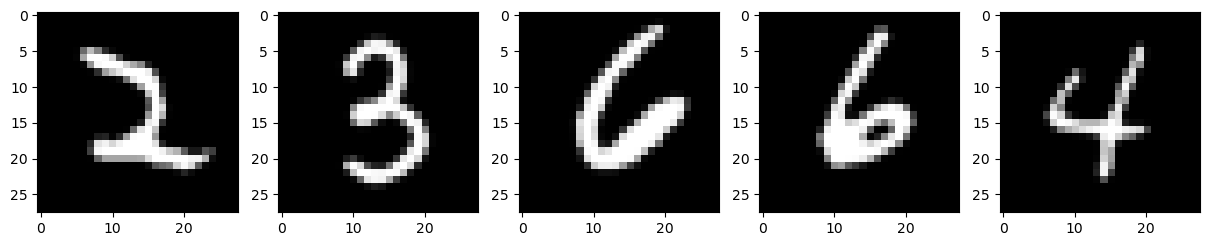

tensor([[  1.1768, 212.9112],
        [  1.8125,  85.1031],
        [  4.1391, 159.8964],
        [  3.4998, 131.2397],
        [  2.3049, 233.1909]], device='cuda:0')


In [8]:
# metricsのサンプルを取得

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike

# Example usage
batch_size = 5
dataset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/MorphoMNIST",
                            columns=['intensity', 'thickness'], train=False)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
intensity = next(iter(data_loader))['intensity'][:, None].float()
thickness = next(iter(data_loader))['thickness'][:, None].float()
metrics = torch.cat([thickness, intensity], dim=1).to(device)
images = next(iter(data_loader))['image']

fig, axes = plt.subplots(1, batch_size, figsize=(15, 3))
for i in range(batch_size):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
plt.show()
print(metrics)

In [14]:
metrics = torch.Tensor(
    [[3.0, 100.0],
     [3.0, 80.0],
     [3.0, 60.0],
     [1.0, 100.0],
     [1.0, 80.0],
     [1.0, 60.0]]
).to(device)

sampling loop time step:   0%|          | 0/50 [00:00<?, ?it/s]

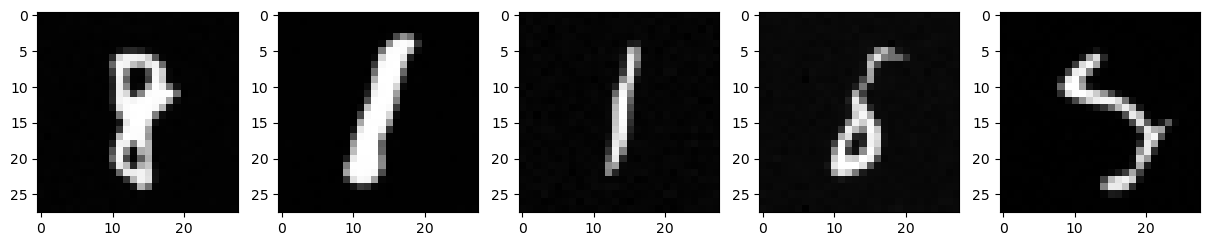

In [10]:
import importlib
from diffusion.utils import sample

importlib.reload(sample)

from diffusion.utils.sample import conditional_ddim_plot_samples


conditional_ddim_plot_samples(denoise_model, eta=0.0, interval=10, batch_size=5, cond=metrics, timesteps=500)